In [50]:
#Importing necessary libraries
import pandas as pd
import re
import emoji
import fasttext
from langdetect import detect

from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [7]:
df = pd.read_csv("MASTER_RAW_kenya_fintech.csv")

In [8]:
df.head()# checking the first few rows

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name
0,695de54e-4b85-4669-ae8c-ad2fdf16667e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"The app still has issues on OTP, because I hav...",1,0,5.1.7,2026-05-11 11:38:40,NaN,NaN,5.1.7,mpesa
1,acd5c061-de13-474b-8645-f628044f2a50,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,si everytime nitakuwa na bundles za ku check m...,2,0,5.1.1,2026-05-11 11:22:24,NaN,NaN,5.1.1,mpesa
2,6f9f52e9-0a00-4f70-a1cc-7687f28465a3,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,this is the stupidest app ever from saf. the w...,1,0,5.1.7,2026-05-11 11:16:47,NaN,NaN,5.1.7,mpesa
3,4a605b22-efc1-4641-b79e-e166b4a7b2e4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Life must go on without this useless app. It u...,1,0,1.14.2,2026-05-11 11:01:23,NaN,NaN,1.14.2,mpesa
4,fd284f23-d966-4be5-b421-a1f0e14c1e13,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,the upgrade is terrible,1,0,NaN,2026-05-11 10:45:52,NaN,NaN,NaN,mpesa


In [ ]:
df.info()#this is to get more information about our dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53507 entries, 0 to 53506
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              53507 non-null  object
 1   userName              53507 non-null  object
 2   userImage             53507 non-null  object
 3   content               53506 non-null  object
 4   score                 53507 non-null  int64 
 5   thumbsUpCount         53507 non-null  int64 
 6   reviewCreatedVersion  47343 non-null  object
 7   at                    53507 non-null  object
 8   replyContent          23933 non-null  object
 9   repliedAt             23933 non-null  object
 10  appVersion            47343 non-null  object
 11  app_name              53507 non-null  object
dtypes: int64(2), object(10)
memory usage: 4.9+ MB


 ## Inspecting raw text ##

In [13]:
print(df['content'].sample(10))

14851                                          it's wow,♥️
34464        it's very fast and reliable with low interest
51944                                                 good
46042    This app is very good, till date I have not se...
29523                                      very convenient
52289                                              chatpat
9125                                                superb
18440                        Working fine, so far so good.
25532         good app I can recommend someone to download
28390                                               pefect
Name: content, dtype: object


### Text Inspection Observations

From the sampled reviews:

-Most reviews are short and concise (e.g., "good", "superb", "perfect").

-A portion of reviews contain **informal language and typos** (e.g., "pefect", "chatpat").

-Some reviews include **special characters and emojis**, indicating expressive user feedback 

-Reviews are generally **positive in tone**, suggesting a bias toward favorable feedback.

-Some reviews contain **sentence-level feedback**, while others are just single-word responses.




## **Text Quality Checks**

## Checking empty reviews

In [17]:
df['is_empty'] = df['content'].isna() | (df['content'].str.strip() == "")# creating an empty column 
df['is_empty'].value_counts()#counts how many true and false

is_empty
False    53506
True         1
Name: count, dtype: int64

The results above indicates that:
 -The dataset is **highly complete**, with almost no missing textual data.

  -Empty reviews are **not a significant data quality issue** in this dataset.


## Checking noisy reviews

In [ ]:
df['length'] = df['content'].astype(str).apply(len)# creates a new column called length to calculate the number of characters in each entry

df['is_noisy'] = df['length'] < 5# creates a column that identifies very short entries

df[['content', 'length']].head()# display 5 rows in the content and length colum.

,content,length
0,"The app still has issues on OTP, because I hav...",311
1,si everytime nitakuwa na bundles za ku check m...,196
2,this is the stupidest app ever from saf. the w...,50
3,Life must go on without this useless app. It u...,125
4,the upgrade is terrible,23


## Checking URLS

In [ ]:
# We create a new column called `has_url` was created to identify text entries containing URLs or website links.
df['has_url'] = df['content'].astype(str).apply(
    lambda x: bool(re.search(r'http[s]?://|www\.', x)))
df[['content', 'has_url']].head()

,content,has_url
0,"The app still has issues on OTP, because I hav...",False
1,si everytime nitakuwa na bundles za ku check m...,False
2,this is the stupidest app ever from saf. the w...,False
3,Life must go on without this useless app. It u...,False
4,the upgrade is terrible,False


## Checking rows with emojis

In [ ]:
# A custom function called `contains_emoji` was created to check whether a text contains emojis. 
# The function loops through each character in the text and checks if it exists in the dictionary.
def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

df['has_emoji'] = df['content'].astype(str).apply(contains_emoji)
df[['content', 'has_emoji']].head()

,content,has_emoji
0,"The app still has issues on OTP, because I hav...",False
1,si everytime nitakuwa na bundles za ku check m...,False
2,this is the stupidest app ever from saf. the w...,False
3,Life must go on without this useless app. It u...,False
4,the upgrade is terrible,False


## Multilingual detection

In [ ]:
# A rule-based method using Swahili keywords was implemented.
#- Reviews containing both English and Swahili elements were classified as **Sheng**.
#- Reviews dominated by Swahili keywords were classified as **Swahili**.

def detect_language_advanced(text):
    text = str(text).lower()
    
    sw_keywords = [
        "sana", "poa", "fiti", "haraka", "vizuri",
        "ni", "na", "hii", "kwa", "lakini"]
    
    try:
        lang = detect(text)
    except:
        return "unknown"

    has_swahili = any(word in text for word in sw_keywords)

    # returning Sheng 
    if lang == "en" and has_swahili:
        return "sheng"

    # returning Pure Swahili
    if has_swahili and lang != "en":
        return "swahili"

    # Otherwise keep detected language
    return lang
df['language'] = df['content'].apply(detect_language_advanced)

df['language'].value_counts().head()

language
en         25091
so          5507
sheng       4981
swahili     3152
af          3111
Name: count, dtype: int64

## Cleaning texts
A `clean_text` function was created to preprocess the text data in the `content` column. It removes URLs, special characters, numbers, and punctuation, then converts all text to lowercase for consistency.

The cleaned text is stored in a new column called `clean_text` by applying the function to each row in the dataset.

In [47]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text) 
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

df['clean_text'] = df['content'].apply(clean_text)

## checking word frequency
This code calculates word frequency by splitting the cleaned text into individual words and counting how often each word appears. It helps identify the most common terms in the dataset for pattern analysis and feature understanding.

In [48]:
word_counts = (
    df['clean_text']
    .str.split()
    .explode()
    .value_counts()
)

word_counts.head(20)

clean_text
app     16573
the     15783
to      11879
good    11738
and     10436
i       10324
it       8114
is       7929
very     6896
you      5094
best     4896
a        4875
this     4730
my       4458
its      4451
loan     4042
for      3982
in       3662
not      3381
nice     3096
Name: count, dtype: int64

## Creating a word cloud
This code combines all cleaned text into a single string and generates a word cloud to visualize the most frequently used words in the dataset. The `WordCloud` object creates a graphical representation where larger words indicate higher frequency, and the plot is displayed using Matplotlib for easy interpretation of key terms and patterns in the data.

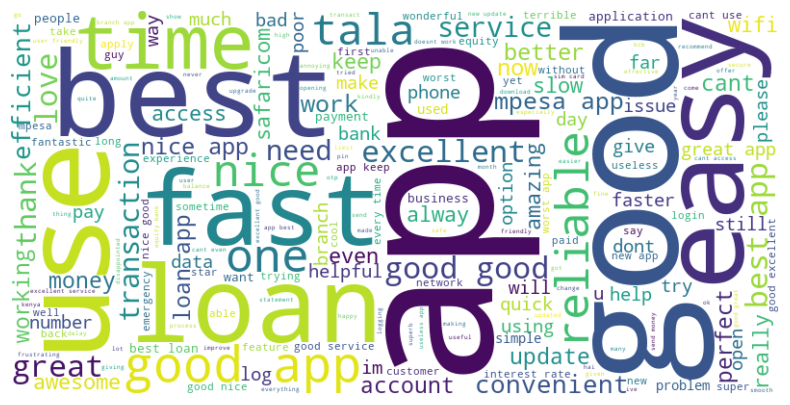

In [51]:

text = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


## Summary outupts

In [52]:
print("Empty reviews:", df['is_empty'].sum())
print("Noisy reviews:", df['is_noisy'].sum())
print("Reviews with URLs:", df['has_url'].sum())
print("Reviews with emojis:", df['has_emoji'].sum())
print("\nTop languages:\n", df['language'].value_counts().head())

Empty reviews: 1
Noisy reviews: 7427
Reviews with URLs: 0
Reviews with emojis: 6046

Top languages:
 language
en         25091
so          5507
sheng       4981
swahili     3152
af          3111
Name: count, dtype: int64
